In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.metrics import silhouette_score

In [8]:
df=pd.read_csv("C:\\TOPS\\tops-Assignment\\Tops-Assignment\Assessment\\Unsupervized Machine Learning\\Customer Personality Analysis\\marketing_campaign.csv",
                sep="\t")

<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
C:\Users\Yash Shah\AppData\Local\Temp\ipykernel_9700\2406207853.py:1: SyntaxWarning: invalid escape sequence '\A'
  df=pd.read_csv("C:\\TOPS\\tops-Assignment\\Tops-Assignment\Assessment\\Unsupervized Machine Learning\\Customer Personality Analysis\\marketing_campaign.csv",


In [9]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [10]:

df.shape

(2240, 29)

In [11]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [13]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [16]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [15]:
df = df.dropna()

In [17]:
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Rows After Removing Duplicates:", len(df))

Duplicate Rows: 0
Rows After Removing Duplicates: 2216


Visualize spending patterns and demographics.

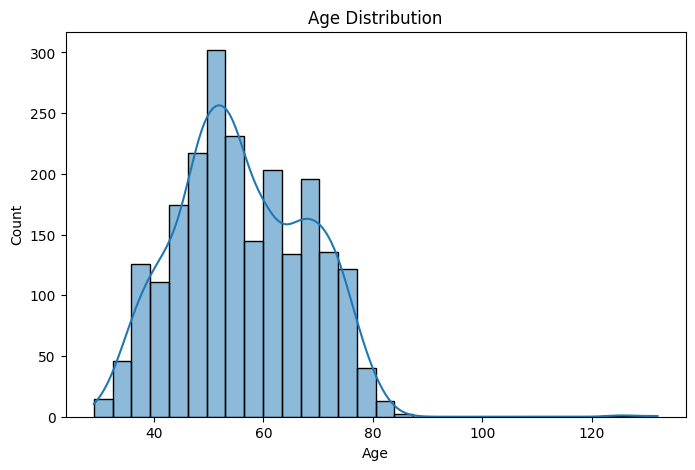

In [18]:
df["Age"] = 2025 - df["Year_Birth"]

plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

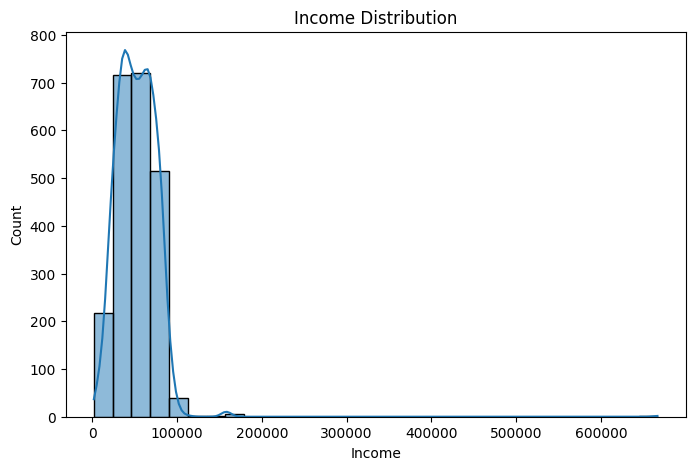

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df["Income"], bins=30, kde=True)

plt.title("Income Distribution")

plt.xlabel("Income")

plt.show()

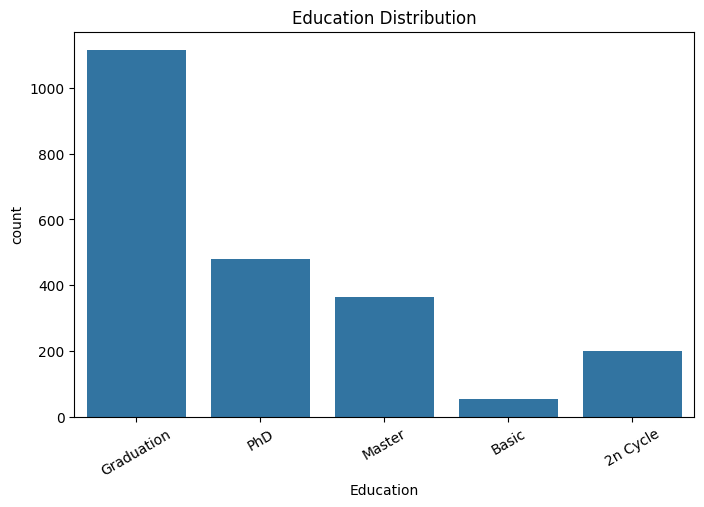

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Education"
)

plt.xticks(rotation=30)

plt.title("Education Distribution")

plt.show()

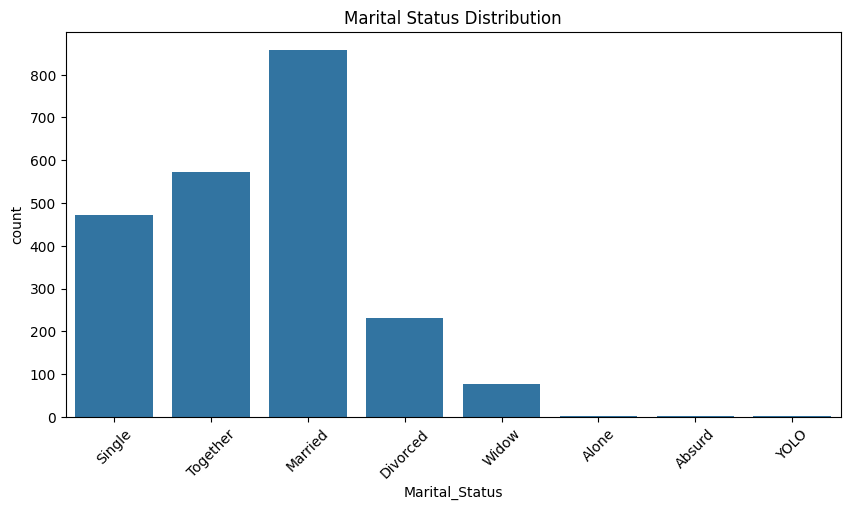

In [21]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Marital_Status"
)

plt.xticks(rotation=45)

plt.title("Marital Status Distribution")

plt.show()

In [22]:
df["Total_Spending"] = (

      df["MntWines"]

    + df["MntFruits"]

    + df["MntMeatProducts"]

    + df["MntFishProducts"]

    + df["MntSweetProducts"]

    + df["MntGoldProds"]

)

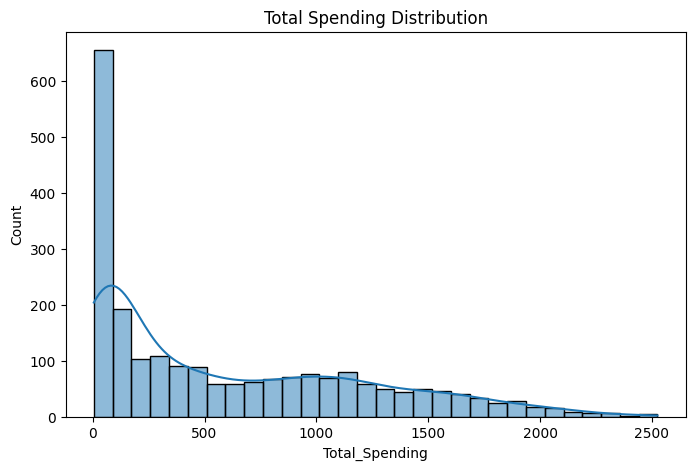

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Total_Spending"],
    bins=30,
    kde=True
)

plt.title("Total Spending Distribution")

plt.show()

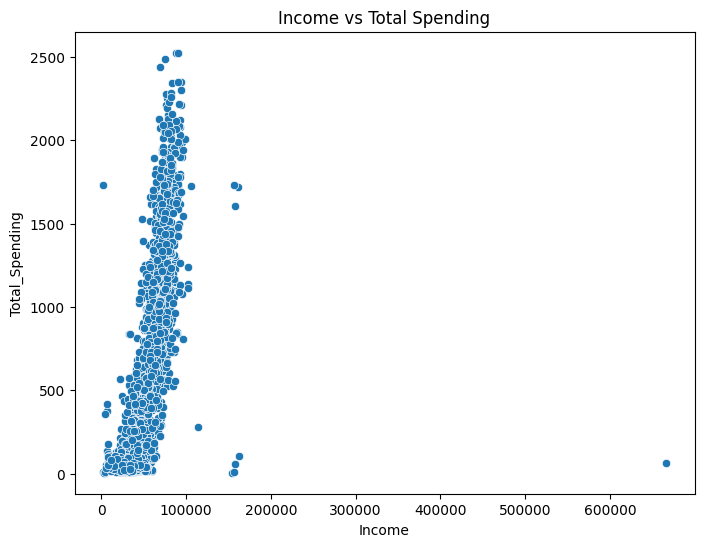

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    data=df,

    x="Income",

    y="Total_Spending"

)

plt.title("Income vs Total Spending")

plt.show()

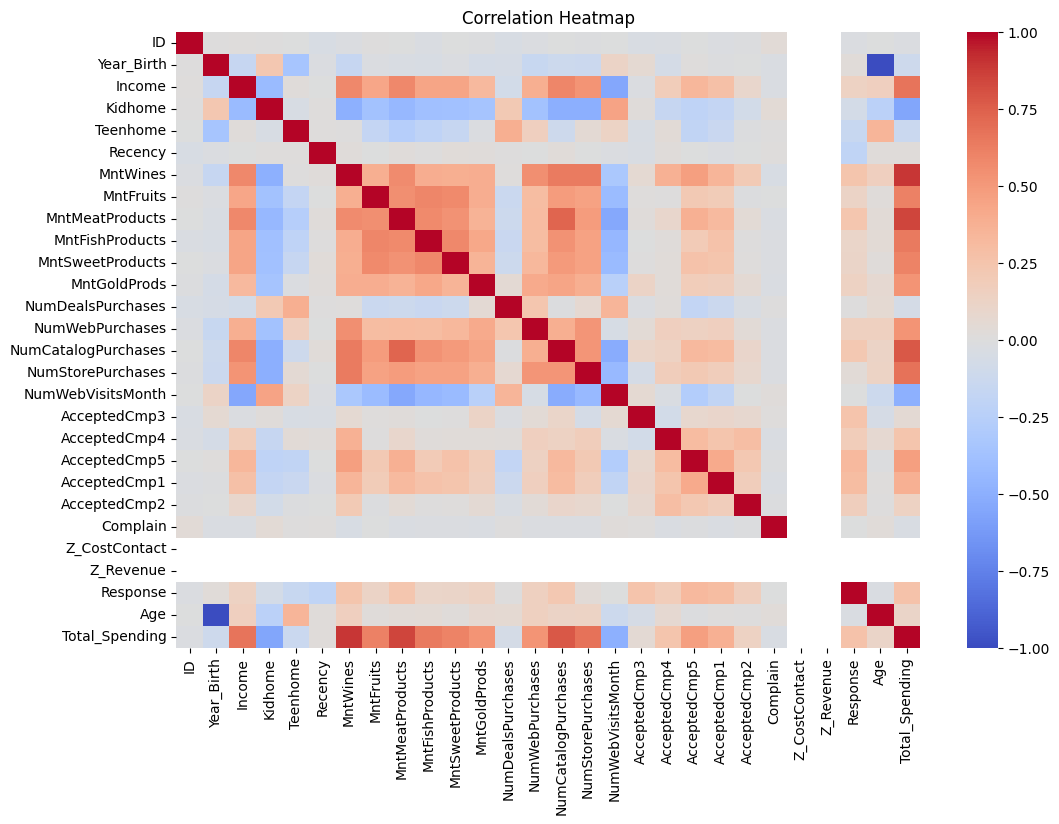

In [25]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(

    numeric_df.corr(),

    cmap="coolwarm",

    annot=False

)

plt.title("Correlation Heatmap")

plt.show()

Normalize Numerical Features (Spending, Income).

In [26]:
features = [
    "Income",
    "Age",
    "Recency",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

X = df[features]

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [28]:
print(X_scaled)

[[ 0.2340627   0.98644293  0.31053212 ...  2.45456767  1.48482696
   0.85003057]
 [-0.23455948  1.23680074 -0.38050944 ... -0.65103787 -0.63388018
  -0.73286728]
 [ 0.76947764  0.31882209 -0.79513438 ...  1.34020333 -0.14682107
  -0.03793652]
 ...
 [ 0.18809052 -1.01641959  1.4507507  ... -0.10298983 -0.36599767
  -0.3854019 ]
 [ 0.67538765  1.06989553 -1.41707178 ...  0.77388702  0.07235553
   0.3288325 ]
 [ 0.02470453  1.23680074 -0.31140528 ... -0.65103787 -0.63388018
  -0.44331279]]


In [29]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=features
)

X_scaled.head()

,Income,Age,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,0.234063,0.986443,0.310532,0.978226,1.549429,1.690227,2.454568,1.484827,0.850031
1,-0.234559,1.236801,-0.380509,-0.872024,-0.637328,-0.717986,-0.651038,-0.633880,-0.732867
2,0.769478,0.318822,-0.795134,0.358511,0.569159,-0.178368,1.340203,-0.146821,-0.037937
3,-1.017239,-1.266777,-0.795134,-0.872024,-0.561922,-0.655551,-0.504892,-0.585174,-0.752171
4,0.240221,-1.016420,1.554407,-0.391671,0.418348,-0.218505,0.152766,-0.000703,-0.559135


Choose optimal number of clusters using Elbow
method.

In [30]:
from sklearn.cluster import KMeans

In [31]:
wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

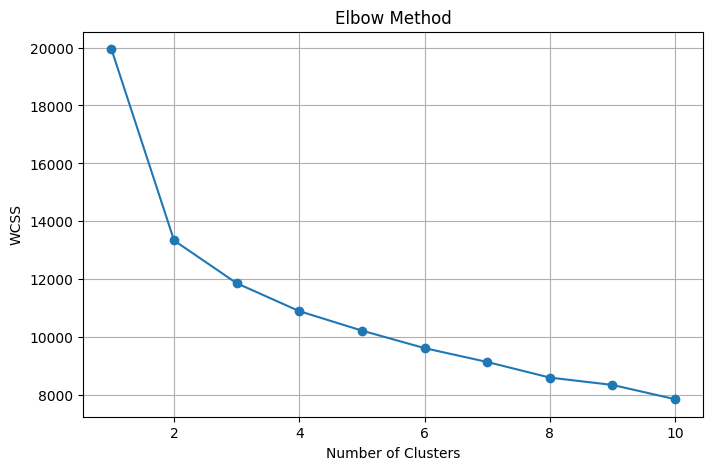

In [32]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [33]:
for i, value in enumerate(wcss, start=1):
    print(f"K = {i}: WCSS = {value:.2f}")

K = 1: WCSS = 19944.00
K = 2: WCSS = 13337.11
K = 3: WCSS = 11859.96
K = 4: WCSS = 10895.44
K = 5: WCSS = 10223.14
K = 6: WCSS = 9617.87
K = 7: WCSS = 9140.04
K = 8: WCSS = 8601.05
K = 9: WCSS = 8347.34
K = 10: WCSS = 7853.42


Apply K-Means Clustering.

In [34]:
kmeans = KMeans(
    n_clusters=4,   # Change this if your elbow suggests a different K
    random_state=42,
    n_init=10
)

In [35]:
kmeans.fit(X_scaled)

KMeans(n_clusters=4, n_init=10, random_state=42)

In [36]:
clusters = kmeans.predict(X_scaled)

In [37]:
df["KMeans_Cluster"] = clusters

In [38]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spending,KMeans_Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,3,11,1,68,1617,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,3,11,0,71,27,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,3,11,0,60,776,2
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,3,11,0,41,53,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,3,11,0,44,422,3


In [39]:
print(df["KMeans_Cluster"].value_counts())

KMeans_Cluster
0    672
3    649
2    561
1    334
Name: count, dtype: int64


In [40]:
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X_scaled.columns
)

centers

,Income,Age,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,-0.581183,-0.222070,-0.869270,-0.622846,-0.497721,-0.588179,-0.508068,-0.511573,-0.441592
1,0.882624,-0.108935,-0.028575,0.639223,1.652303,1.245890,1.699607,1.693212,0.916148
2,0.763342,0.306327,0.037626,1.055219,0.175734,0.626421,0.186795,0.161389,0.465197
3,-0.512184,0.021587,0.884960,-0.596147,-0.486866,-0.573619,-0.510079,-0.481148,-0.416323


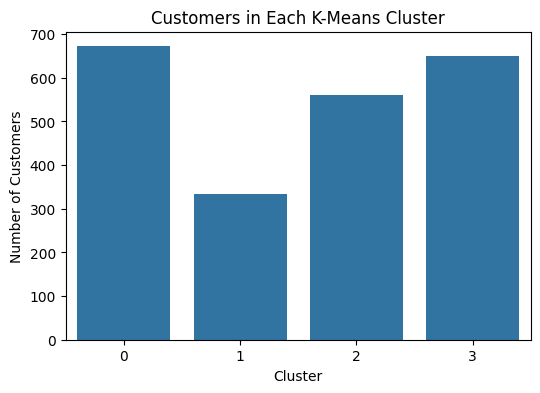

In [41]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="KMeans_Cluster",
    data=df
)

plt.title("Customers in Each K-Means Cluster")

plt.xlabel("Cluster")

plt.ylabel("Number of Customers")

plt.show()

Apply Hierarchical Clustering and Compare.

In [42]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

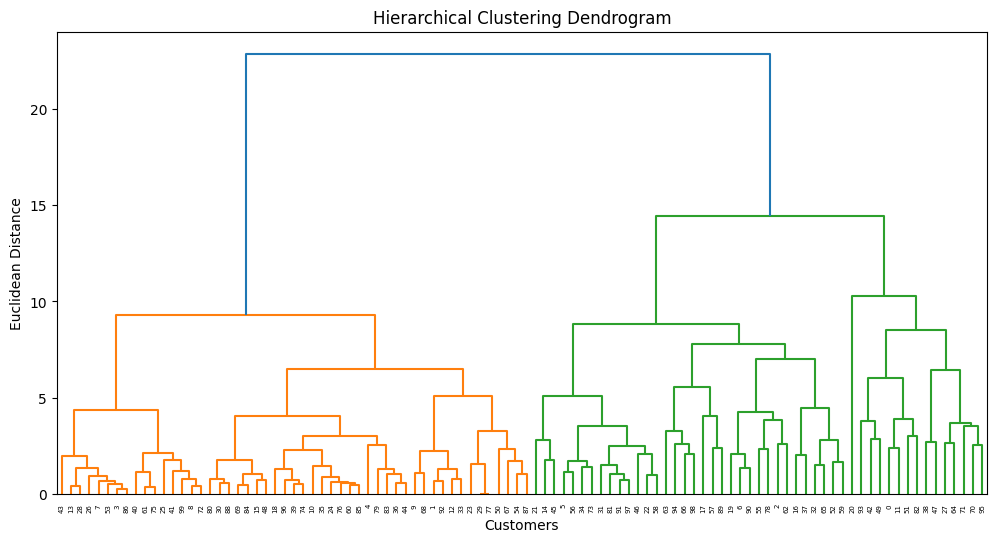

In [43]:
plt.figure(figsize=(12,6))

linked = linkage(
    X_scaled.iloc[:100],
    method="ward"
)

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Customers")

plt.ylabel("Euclidean Distance")

plt.show()

In [44]:
n_clusters = 4

In [45]:
hc = AgglomerativeClustering(
    n_clusters=4
)

hc_clusters = hc.fit_predict(X_scaled)

In [46]:
df["Hierarchical_Cluster"] = hc_clusters

In [47]:
print(df["Hierarchical_Cluster"].value_counts())

Hierarchical_Cluster
1    716
0    659
3    535
2    306
Name: count, dtype: int64


In [48]:
comparison = pd.DataFrame({

    "KMeans":

        df["KMeans_Cluster"].value_counts().sort_index(),

    "Hierarchical":

        df["Hierarchical_Cluster"].value_counts().sort_index()

})

comparison

,KMeans,Hierarchical
0,672,659
1,334,716
2,561,306
3,649,535


Visualize Clusters using PCA.


In [49]:
from sklearn.decomposition import PCA

In [50]:
pca = PCA(n_components=2)

In [51]:
X_pca = pca.fit_transform(X_scaled)

In [52]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

In [53]:
pca_df["Cluster"] = df["KMeans_Cluster"]

In [54]:
pca_df.head()

,PC1,PC2,Cluster
0,3.618216,0.088902,1.0
1,-1.602214,1.102979,0.0
2,1.043943,0.092677,2.0
3,-1.935235,-1.332702,0.0
4,-0.142802,-0.775581,3.0


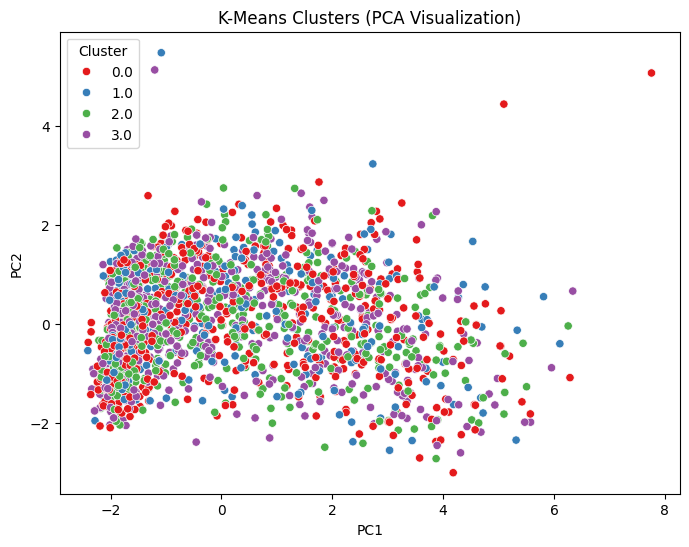

In [55]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1"
)

plt.title("K-Means Clusters (PCA Visualization)")

plt.show()

In [56]:
pca_df_h = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df_h["Cluster"] = df["Hierarchical_Cluster"]

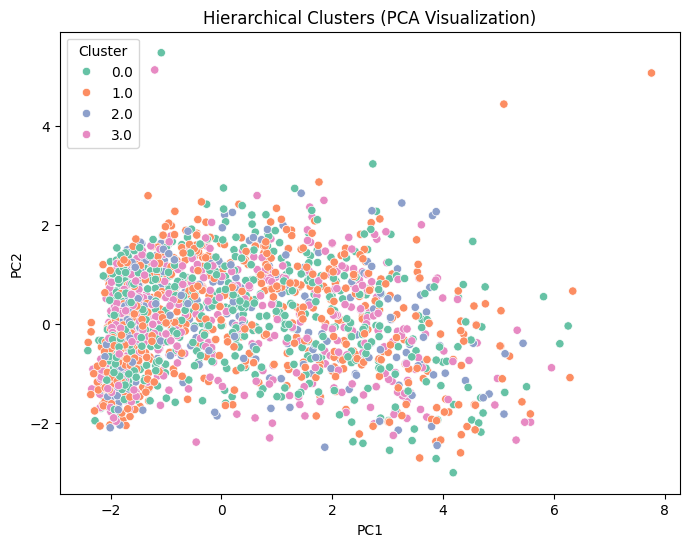

In [57]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df_h,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2"
)

plt.title("Hierarchical Clusters (PCA Visualization)")

plt.show()

In [58]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.42869871 0.11997437]


Profile Each Cluster

In [59]:
df["Total_Purchases"] = (
    df["NumWebPurchases"] +
    df["NumCatalogPurchases"] +
    df["NumStorePurchases"]
)

In [61]:
cluster_profile = df.groupby("KMeans_Cluster").agg({

    "Age":"mean",

    "Income":"mean",

    "Total_Spending":"mean",

    "Total_Purchases":"mean",

    "Recency":"mean"

}).round(2)

cluster_profile

,Age,Income,Total_Spending,Total_Purchases,Recency
KMeans_Cluster,,,,,
0,53.52,37642.62,173.75,7.68,23.81
1,54.87,74460.60,1377.78,19.41,48.19
2,59.85,71458.58,1151.36,19.55,50.10
3,56.43,39331.21,188.64,8.04,74.59


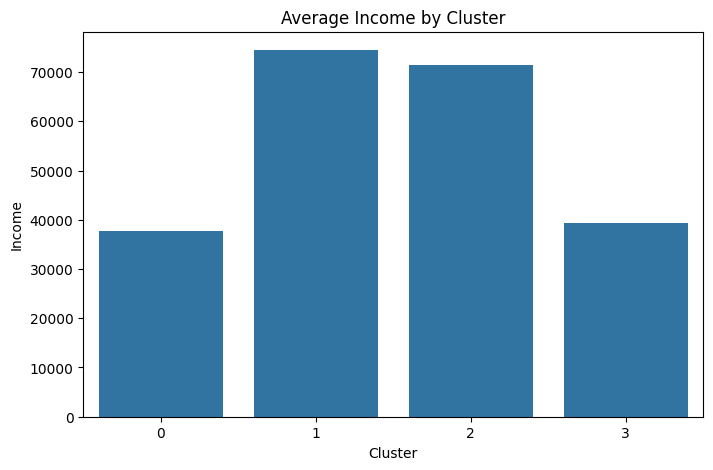

In [62]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_profile.index,
    y=cluster_profile["Income"]
)

plt.title("Average Income by Cluster")

plt.xlabel("Cluster")

plt.ylabel("Income")

plt.show()

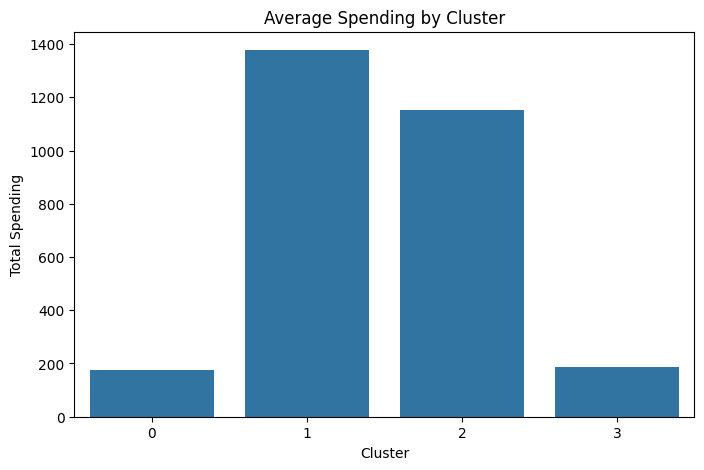

In [63]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_profile.index,
    y=cluster_profile["Total_Spending"]
)

plt.title("Average Spending by Cluster")

plt.xlabel("Cluster")

plt.ylabel("Total Spending")

plt.show()

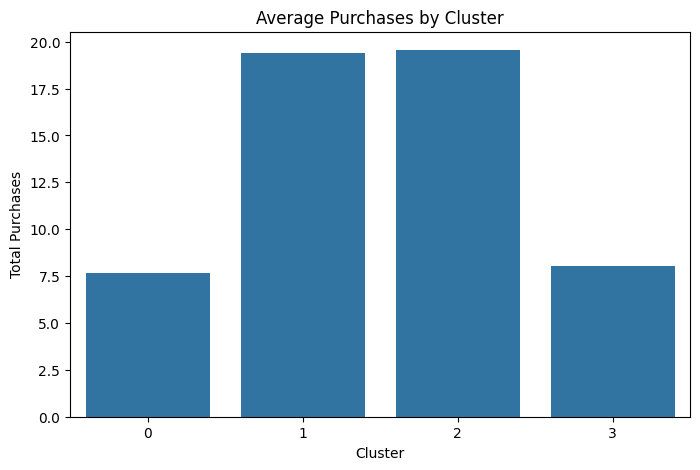

In [64]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_profile.index,
    y=cluster_profile["Total_Purchases"]
)

plt.title("Average Purchases by Cluster")

plt.xlabel("Cluster")

plt.ylabel("Total Purchases")

plt.show()

Label Original Dataset with Cluster IDs.

In [65]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spending,KMeans_Cluster,Hierarchical_Cluster,Total_Purchases
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,3,11,1,68,1617,1,0,22
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,3,11,0,71,27,0,1,4
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,3,11,0,60,776,2,0,20
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,3,11,0,41,53,0,1,6
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,3,11,0,44,422,3,3,14


In [66]:
df[[
    "ID",
    "Age",
    "Income",
    "Total_Spending",
    "KMeans_Cluster"
]].head(10)

,ID,Age,Income,Total_Spending,KMeans_Cluster
0,5524,68,58138.0,1617,1
1,2174,71,46344.0,27,0
2,4141,60,71613.0,776,2
3,6182,41,26646.0,53,0
4,5324,44,58293.0,422,3
5,7446,58,62513.0,716,0
6,965,54,55635.0,590,2
7,6177,40,33454.0,169,0
8,4855,51,30351.0,46,0
9,5899,75,5648.0,49,3


In [67]:
df.to_csv(
    "Customer_Segmentation_Result.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


Recommend Marketing Strategy per Cluster

In [68]:
cluster_profile

,Age,Income,Total_Spending,Total_Purchases,Recency
KMeans_Cluster,,,,,
0,53.52,37642.62,173.75,7.68,23.81
1,54.87,74460.60,1377.78,19.41,48.19
2,59.85,71458.58,1151.36,19.55,50.10
3,56.43,39331.21,188.64,8.04,74.59


In [69]:
marketing_strategy = pd.DataFrame({

    "Cluster":[0,1,2,3],

    "Customer Type":[
        "Budget Customers",
        "Premium Customers",
        "Regular Customers",
        "Loyal High-Value Customers"
    ],

    "Marketing Strategy":[
        "Offer discounts and coupons to increase purchases.",
        "Promote premium products and exclusive memberships.",
        "Recommend personalized product bundles and seasonal offers.",
        "Provide loyalty rewards, VIP benefits, and early access to new products."
    ]

})

marketing_strategy

,Cluster,Customer Type,Marketing Strategy
0,0,Budget Customers,Offer discounts and coupons to increase purcha...
1,1,Premium Customers,Promote premium products and exclusive members...
2,2,Regular Customers,Recommend personalized product bundles and sea...
3,3,Loyal High-Value Customers,"Provide loyalty rewards, VIP benefits, and ear..."


In [70]:
for index, row in marketing_strategy.iterrows():

    print(f"\nCluster {row['Cluster']}")

    print(f"Customer Type : {row['Customer Type']}")

    print(f"Strategy      : {row['Marketing Strategy']}")


Cluster 0
Customer Type : Budget Customers
Strategy      : Offer discounts and coupons to increase purchases.

Cluster 1
Customer Type : Premium Customers
Strategy      : Promote premium products and exclusive memberships.

Cluster 2
Customer Type : Regular Customers
Strategy      : Recommend personalized product bundles and seasonal offers.

Cluster 3
Customer Type : Loyal High-Value Customers
Strategy      : Provide loyalty rewards, VIP benefits, and early access to new products.


In [71]:
marketing_strategy.to_csv(
    "Marketing_Strategy.csv",
    index=False
)

print("Marketing strategy saved successfully.")

Marketing strategy saved successfully.
